In [1]:
import pandas as pd
import glob 
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

print("Library berhasil diimport.")

Library berhasil diimport.


In [2]:
file_pattern = "data*.csv"
all_trend_files = glob.glob(file_pattern)

print(f"Menemukan {len(all_trend_files)} file Google Trends.")

all_trends_data = []

for file in all_trend_files:
    try:
        df_trend = pd.read_csv(file, skiprows=2)
        df_trend.rename(columns={'Minggu': 'minggu'}, inplace=True)
        
        data_column_name = df_trend.columns[1]
        df_trend[data_column_name] = df_trend[data_column_name].replace('<1', 0.5)
        df_trend[data_column_name] = pd.to_numeric(df_trend[data_column_name])
       
        df_trend['minggu'] = pd.to_datetime(df_trend['minggu'])
        
        # Standardisasi tanggal ke hari Senin
        df_trend['minggu_standar'] = df_trend['minggu'] - pd.to_timedelta(df_trend['minggu'].dt.dayofweek, unit='d')
        df_trend.set_index('minggu_standar', inplace=True)
        
        all_trends_data.append(df_trend[[data_column_name]])
        
    except Exception as e:
        print(f"Gagal memproses file {file}: {e}")

df_trends_combined = pd.concat(all_trends_data, axis=1)
df_trends_combined.columns = [f'tren_{i}' for i in range(len(df_trends_combined.columns))]

print("\n--- Data Google Trends Gabungan (Contoh 5 baris pertama) ---")
df_trends_combined.to_csv('data_gtrend_gabungan.csv', sep=';')
print(df_trends_combined.head())

Menemukan 16 file Google Trends.
Gagal memproses file data_anomali.csv: index 1 is out of bounds for axis 0 with size 1
Gagal memproses file data_gtrend_gabungan.csv: index 1 is out of bounds for axis 0 with size 1

--- Data Google Trends Gabungan (Contoh 5 baris pertama) ---
                tren_0  tren_1  tren_2  tren_3  tren_4  tren_5  tren_6  \
minggu_standar                                                           
2019-12-23           2     0.0      18     0.0     0.0      25       0   
2019-12-30           2     0.0      20     0.0     0.0      25       0   
2020-01-06           3     0.0      22     0.0     0.0      25       0   
2020-01-13           3     0.0      21     0.0     0.0      25       0   
2020-01-20           4     0.0      23     0.0     0.0      25       0   

                tren_7  tren_8  tren_9  tren_10  tren_11  tren_12  tren_13  
minggu_standar                                                              
2019-12-23         0.0      35     0.5        0   

In [3]:
file_anomali = "hasil_feature_engineering_noduplikat.csv" 
NAMA_KOLOM_TANGGAL = 'week_start'
NAMA_KOLOM_SKOR_ASLI = 'anomaly_score' 
NAMA_KOLOM_WOW = 'week_on_week_change'
NAMA_KOLOM_SPIKE = 'spike_from_mean'

try:
    df_anomaly = pd.read_csv(file_anomali)
    cols_to_use = [NAMA_KOLOM_TANGGAL, NAMA_KOLOM_SKOR_ASLI, NAMA_KOLOM_WOW, NAMA_KOLOM_SPIKE]
    df_anomaly_selected = df_anomaly[cols_to_use].copy()
    
    df_anomaly_selected[NAMA_KOLOM_TANGGAL] = pd.to_datetime(df_anomaly_selected[NAMA_KOLOM_TANGGAL])
    
    # Standardisasi tanggal ke hari Senin
    df_anomaly_selected['minggu_standar'] = df_anomaly_selected[NAMA_KOLOM_TANGGAL] - pd.to_timedelta(df_anomaly_selected[NAMA_KOLOM_TANGGAL].dt.dayofweek, unit='d')
    df_anomaly_selected.set_index('minggu_standar', inplace=True)
    df_anomaly_selected.to_csv('data_anomali.csv', sep=';')
    
    print("\n--- Data Anomali Siap (Contoh 5 baris pertama) ---")
    print(df_anomaly_selected.head())

except Exception as e:
    print(f"GAGAL memuat data anomali. Periksa nama file dan nama kolom: {e}")


--- Data Anomali Siap (Contoh 5 baris pertama) ---
               week_start  anomaly_score  week_on_week_change  spike_from_mean
minggu_standar                                                                
2020-01-06     2020-01-06      -0.081784             0.000000         0.000000
2020-01-13     2020-01-13      -0.101185           168.478261        45.722714
2020-01-20     2020-01-20      -0.001520            -0.404858        26.153846
2020-01-27     2020-01-27       0.012686            10.162602        26.635514
2020-02-03     2020-02-03       0.040609             5.535055         8.952381


In [4]:
df_merged = pd.merge(df_anomaly_selected, df_trends_combined, left_index=True, right_index=True, how='inner')

# Menghapus baris yang mungkin memiliki data kosong
df_merged.dropna(inplace=True)
df_merged = df_merged[df_merged.index >= '2020-01-01']
print(f"\nData telah difilter. Tanggal mulai baru: {df_merged.index.min()}")

print("\n--- Data Gabungan Anomali & Trends (Contoh 5 baris pertama SETELAH FILTER) ---")
print(df_merged.head())

df_to_save = df_merged.reset_index() 
try:
    df_to_save.to_csv('gabungan_anomali_dan_trends.csv', index=False)
    print("\nFile 'gabungan_anomali_dan_trends.csv' berhasil disimpan dengan kolom tanggal.")
except Exception as e:
    print(f"\nGagal menyimpan file: {e}")


Data telah difilter. Tanggal mulai baru: 2020-01-06 00:00:00

--- Data Gabungan Anomali & Trends (Contoh 5 baris pertama SETELAH FILTER) ---
               week_start  anomaly_score  week_on_week_change  \
minggu_standar                                                  
2020-01-06     2020-01-06      -0.081784             0.000000   
2020-01-13     2020-01-13      -0.101185           168.478261   
2020-01-20     2020-01-20      -0.001520            -0.404858   
2020-01-27     2020-01-27       0.012686            10.162602   
2020-02-03     2020-02-03       0.040609             5.535055   

                spike_from_mean  tren_0  tren_1  tren_2  tren_3  tren_4  \
minggu_standar                                                            
2020-01-06             0.000000       3     0.0      22     0.0     0.0   
2020-01-13            45.722714       3     0.0      21     0.0     0.0   
2020-01-20            26.153846       4     0.0      23     0.0     0.0   
2020-01-27            26.63

In [5]:
# df_merged['skor_inversi'] = -1 * df_merged[NAMA_KOLOM_SKOR_ASLI]
# kondisi_lonjakan = (df_merged[NAMA_KOLOM_WOW] > 0) & (df_merged[NAMA_KOLOM_SPIKE] > 0)
# df_merged['skor_intensitas_lonjakan'] = np.where(kondisi_lonjakan, df_merged['skor_inversi'], 0)

# 1. Inversi skor (agar anomali menjadi positif)
df_merged['skor_inversi'] = -1 * df_merged[NAMA_KOLOM_SKOR_ASLI]

# 2. Cek kondisi lonjakan
kondisi_lonjakan = (df_merged[NAMA_KOLOM_WOW] > 0) & (df_merged[NAMA_KOLOM_SPIKE] > 0)

# 3. LOGIKA BARU YANG BENAR:
df_merged['skor_intensitas_lonjakan'] = np.where(
    (kondisi_lonjakan) & (df_merged['skor_inversi'] > 0), # Syarat: Lonjakan DAN Anomali
    df_merged['skor_inversi'],                           # Nilai jika Benar
    0                                             # Nilai jika Salah (termasuk anomali penurunan & data normal)
)

In [6]:
trend_columns = [col for col in df_merged.columns if col.startswith('tren_')]
scaler = StandardScaler()

if trend_columns:
    df_merged[trend_columns] = scaler.fit_transform(df_merged[trend_columns])
    df_merged['indeks_minat_publik'] = df_merged[trend_columns].mean(axis=1)
    
    print("\n--- Data Final Siap untuk Korelasi (Contoh 5 baris pertama) ---")
    print(df_merged[['skor_intensitas_lonjakan', 'indeks_minat_publik']].head())
    df_merged.to_csv('skorintensitas.csv')
else:
    print("\nGAGAL: Tidak ada kolom 'tren_' yang ditemukan. Periksa file Google Trends Anda.")


--- Data Final Siap untuk Korelasi (Contoh 5 baris pertama) ---
                skor_intensitas_lonjakan  indeks_minat_publik
minggu_standar                                               
2020-01-06                      0.000000            -0.519487
2020-01-13                      0.101185            -0.467339
2020-01-20                      0.000000            -0.463504
2020-01-27                      0.000000            -0.375660
2020-02-03                      0.000000            -0.433508


In [7]:
if 'indeks_minat_publik' in df_merged.columns:
    variabel_anomali = df_merged['skor_intensitas_lonjakan']
    variabel_trends = df_merged['indeks_minat_publik']
    
    clean_df = df_merged[['skor_intensitas_lonjakan', 'indeks_minat_publik']].replace([np.inf, -np.inf], np.nan).dropna()
    
    variabel_anomali_clean = clean_df['skor_intensitas_lonjakan']
    variabel_trends_clean = clean_df['indeks_minat_publik']
    
    korelasi, p_value = pearsonr(variabel_anomali_clean, variabel_trends_clean)

    print("\n" + "="*40)
    print("--- HASIL ANALISIS KORELASI PEARSON ---")
    print(f"Koefisien Korelasi (r): {korelasi:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("HASIL: Signifikan secara statistik (p < 0.05).")
        print("Ada hubungan linear yang signifikan antara lonjakan anomali dan minat publik.")
    else:
        print("HASIL: Tidak signifikan secara statistik (p >= 0.05).")
        print("Tidak ada hubungan linear yang signifikan yang terdeteksi.")
    print("="*40 + "\n")
else:
    print("\nAnalisis korelasi dilewati karena 'indeks_minat_publik' gagal dibuat.")


--- HASIL ANALISIS KORELASI PEARSON ---
Koefisien Korelasi (r): 0.4613
P-value: 0.0000
HASIL: Signifikan secara statistik (p < 0.05).
Ada hubungan linear yang signifikan antara lonjakan anomali dan minat publik.



Membuat grafik visualisasi...
Grafik berhasil disimpan sebagai: visualisasi_korelasi_anomali_vs_trends.png


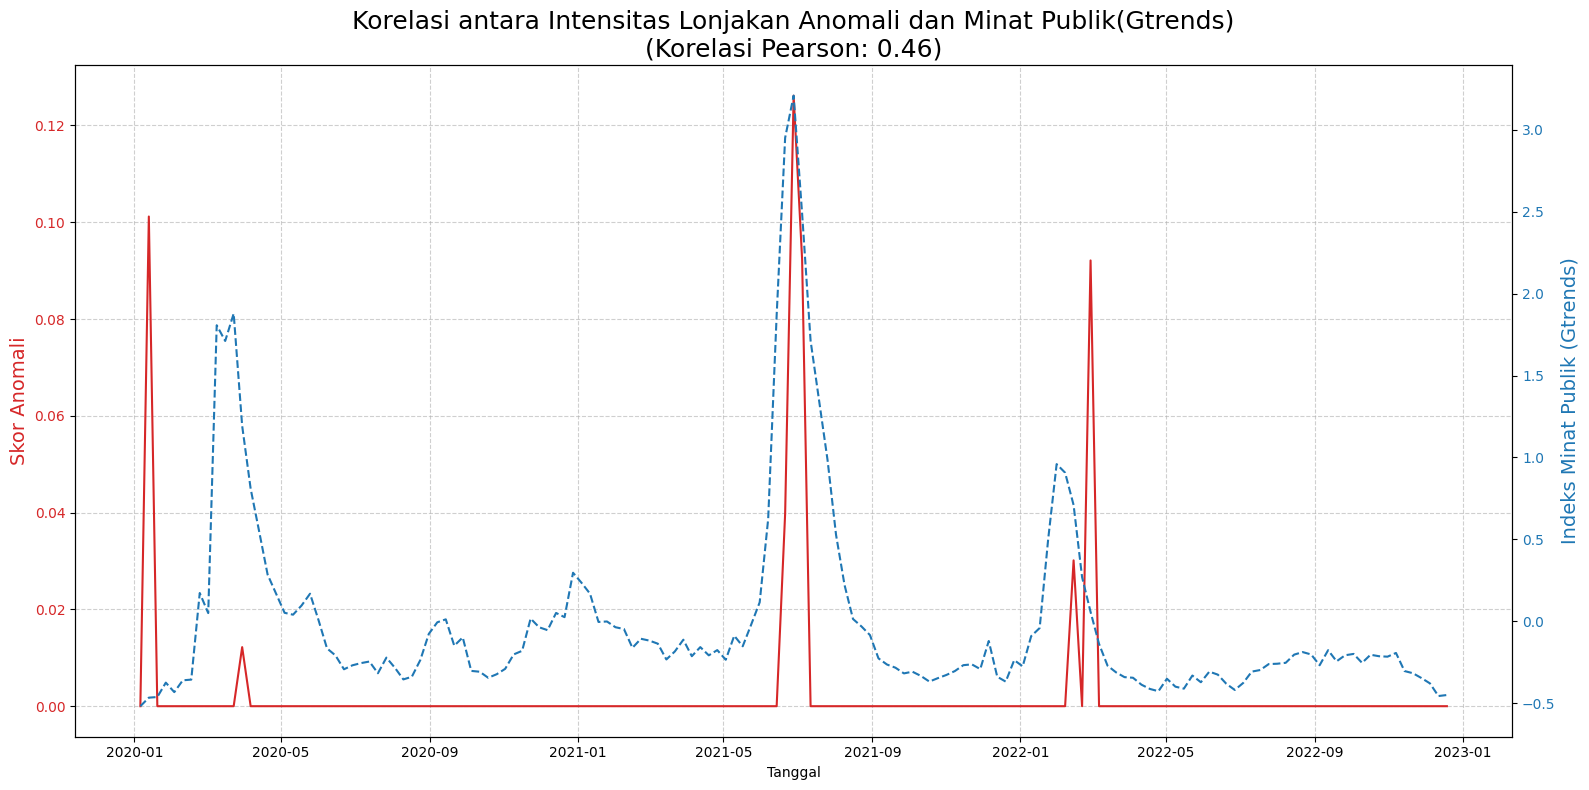

In [8]:
if 'indeks_minat_publik' in df_merged.columns:
    print("Membuat grafik visualisasi...")
    fig, ax1 = plt.subplots(figsize=(16, 8))

    color = 'tab:red'
    ax1.set_xlabel('Tanggal')
    ax1.set_ylabel('Skor Anomali', color=color, fontsize=14)
    ax1.plot(df_merged.index, df_merged['skor_intensitas_lonjakan'], color=color, label='Skor Anomali')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Indeks Minat Publik (Gtrends)', color=color, fontsize=14)
    ax2.plot(df_merged.index, df_merged['indeks_minat_publik'], color=color, linestyle='--', label='Minat Publik (Google Trends)')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Korelasi antara Intensitas Lonjakan Anomali dan Minat Publik(Gtrends)\n(Korelasi Pearson: {korelasi:.2f})', fontsize=18)
    fig.tight_layout()

    nama_file_grafik = 'visualisasi_korelasi_anomali_vs_trends.png'
    plt.savefig(nama_file_grafik)
    print(f"Grafik berhasil disimpan sebagai: {nama_file_grafik}")
else:
    print("Visualisasi dilewati.")